# Hetrozygosity
Calculate heterozygosity ratios and visualize them nicely.

## Libraries

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

if os.getcwd().startswith("/home/lakrids"):
    path_prefix = "/home/lakrids/GenomeDK"
else:
    path_prefix = "/faststorage/project/"
    
# define species and username so that the files can be found
species = "Panthera_tigris"
colours = {"Panthera_tigris":"orange",
              "Elephas_maximus":"teal"}


## Data import

In [2]:
merged_counts_df = pd.read_csv(f"{path_prefix}/megaFauna/sa_megafauna/data/{species}/VCF/snp_counts/merged_counts.txt", sep="\t")
cov_df = pd.read_csv(f"{path_prefix}/megaFauna/sa_megafauna/data/{species}/ref/samples_coverage_stats_filtered.txt", sep="\t")

### Create a merged dataframe

In [3]:
merged_df = merged_counts_df.merge(cov_df[['IND_ID', 'len_covered_raw_A', 'len_covered_raw_X']],
                                  left_on='IND_ID', right_on='IND_ID', how='left')
merged_df

,IND_ID,autosomal,chrX,chrY,chrM,len_covered_raw_A,len_covered_raw_X
0,SAMN20424165,1529841,0,0,0,2267484337,126498095
1,SAMN17816832,617442,12393,0,0,2266902973,127438727
2,SAMN20424166,1564835,0,0,0,2265776446,126985917
3,SAMN02086964,1234377,0,0,0,2270932865,127647988
4,SAMN17816833,1281189,0,0,0,2269118605,127259368
...,...,...,...,...,...,...,...
87,SAMN20424162,1386162,15107,0,0,2265534734,127277285
88,SAMN17816817,1098925,23354,0,0,2268297583,127534696
89,SAMN17816830,1428712,0,0,0,2267825688,126851210
90,SAMN20424163,1411250,0,0,0,2266363960,125735674


## Calculate heterozygosity ratios.
Mostly for autosomes and optionally X. Y Chromosome is missing for now, because i couldn't really calculate the number of SNPs (not sure why).

In [4]:
merged_df['het_autosomal'] = merged_df['autosomal'] / merged_df['len_covered_raw_A']
merged_df['het_chrX'] = merged_df['chrX'] / merged_df['len_covered_raw_X']
merged_df

,IND_ID,autosomal,chrX,chrY,chrM,len_covered_raw_A,len_covered_raw_X,het_autosomal,het_chrX
0,SAMN20424165,1529841,0,0,0,2267484337,126498095,0.000675,0.000000
1,SAMN17816832,617442,12393,0,0,2266902973,127438727,0.000272,0.000097
2,SAMN20424166,1564835,0,0,0,2265776446,126985917,0.000691,0.000000
3,SAMN02086964,1234377,0,0,0,2270932865,127647988,0.000544,0.000000
4,SAMN17816833,1281189,0,0,0,2269118605,127259368,0.000565,0.000000
...,...,...,...,...,...,...,...,...,...
87,SAMN20424162,1386162,15107,0,0,2265534734,127277285,0.000612,0.000119
88,SAMN17816817,1098925,23354,0,0,2268297583,127534696,0.000484,0.000183
89,SAMN17816830,1428712,0,0,0,2267825688,126851210,0.000630,0.000000
90,SAMN20424163,1411250,0,0,0,2266363960,125735674,0.000623,0.000000


## The plot

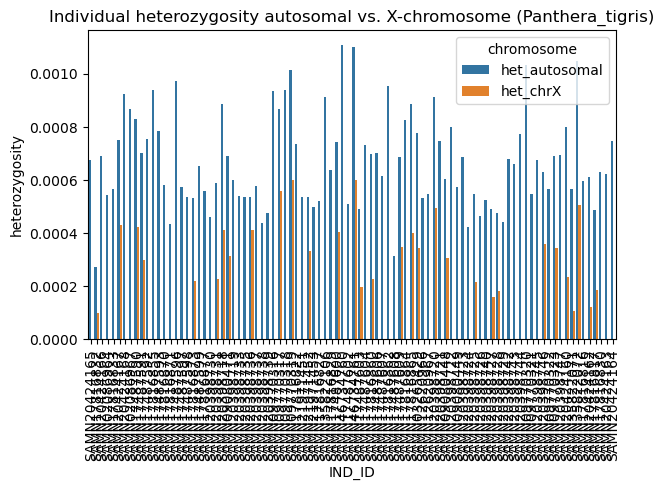

In [5]:
melted = merged_df.melt(id_vars='IND_ID', 
                     value_vars=['het_autosomal', 'het_chrX'], 
                     var_name='chromosome', value_name='heterozygosity')

sns.barplot(data=melted, x='IND_ID', y='heterozygosity', hue='chromosome')
plt.xticks(rotation=90)
plt.tight_layout()
plt.title(f"Individual heterozygosity autosomal vs. X-chromosome ({species})")
plt.show()

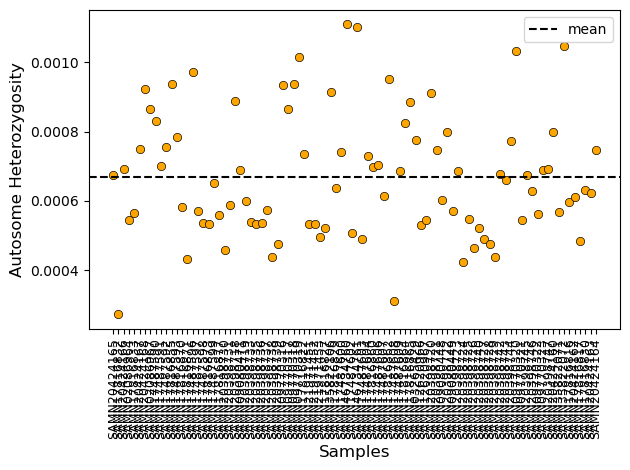

In [6]:
sns.scatterplot(data=merged_df, x='IND_ID', y='het_autosomal', color=colours.get(species), edgecolor='black')
plt.xticks(rotation=90, fontsize=9)
#plt.title(f"Individual autosomal heterozygosity ({species})")

# get mean value
mean_val = merged_df['het_autosomal'].mean()
plt.axhline(mean_val, color='black', linestyle='--', label="mean")
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Autosome Heterozygosity", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
float(merged_df['het_autosomal'].mean())

0.0006683723616536197